# Analisis Clustering Cacat Produk Industri Manufaktur

```
=============================================================================
ANALISIS CLUSTERING CACAT PRODUK INDUSTRI MANUFAKTUR
Dataset : defects_data.csv
Tujuan  : Melakukan clustering terhadap data cacat produk untuk menemukan
          pola/segmen cacat produk yang bisa dipakai untuk insight bisnis
          (mis. jenis inspeksi mana yang paling banyak menangani cacat berat,
          lokasi cacat mana yang biaya perbaikannya tinggi, dsb.)

Struktur pipeline (sesuai requirement tugas UAS):
  1. Import Library
  2. Load Data & Pemahaman Awal (EDA ringkas)
  3. Data Cleaning / Preprocessing
       3.1 Cek & tangani Missing Value (aturan: >75% kosong -> drop kolom,
           selain itu -> imputasi sesuai tipe data)
       3.2 Cek & tangani Duplikasi Data
       3.3 Cek & tangani Outlier (metode IQR)
       3.4 Cek & tangani Noise / data tidak valid
       3.5 Diskusi Class Imbalance (apakah relevan untuk clustering?)
  4. Drop kolom yang berpotensi menyebabkan data leakage / bukan informatif
  5. Feature Engineering
  6. Encoding kategorikal
  7. Feature Scaling
  8. Pemilihan Model Clustering + Hyperparameter Tuning
  9. Evaluasi (Silhouette, Davies-Bouldin, Calinski-Harabasz)
 10. Interpretasi Model dengan SHAP (surrogate model) -> insight per cluster
 11. Visualisasi (PCA 2D, distribusi fitur per cluster, dst.) dengan palet
     warna RGB random, ditampilkan langsung di output (bukan cuma disimpan)
 12. Simpan hasil akhir (dataset + label cluster) ke CSV
=============================================================================
```

## IMPORT LIBRARY

In [1]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# -----------------------------------------------------------------------
# Util: generator palet warna RGB RANDOM (sesuai request "color palette RGB
# random"). Di-seed supaya hasil tetap reproducible antar run, tapi warnanya
# tetap "acak" (bukan palet default matplotlib/seaborn).
# -----------------------------------------------------------------------
def random_rgb_palette(n, seed=SEED):
    rng = np.random.RandomState(seed)
    colors = []
    for _ in range(n):
        r, g, b = rng.randint(30, 230, size=3) / 255.0
        colors.append((r, g, b))
    return colors


def random_cmap(seed=SEED):
    rng = np.random.RandomState(seed + 1)
    stops = []
    for i in np.linspace(0, 1, 6):
        r, g, b = rng.randint(20, 235, size=3) / 255.0
        stops.append((i, (r, g, b)))
    return mcolors.LinearSegmentedColormap.from_list("random_rgb_cmap", stops)


print("Library berhasil di-import.")

Library berhasil di-import.


## LOAD DATA

In [2]:
df_raw = pd.read_csv("data/defects_data.csv")
print("Ukuran data awal:", df_raw.shape)
display_head = df_raw.head()
print(display_head)

print("\nInfo tipe data:")
print(df_raw.dtypes)

print("\nStatistik deskriptif (numerik):")
print(df_raw.describe(include="number"))

print("\nStatistik deskriptif (kategorikal):")
print(df_raw.describe(include="object"))

df = df_raw.copy()

Ukuran data awal: (1000, 8)
   defect_id  product_id defect_type defect_date defect_location  severity  inspection_method  repair_cost
0          1          15  Structural    6/6/2024       Component     Minor  Visual Inspection       245.47
1          2           6  Functional   4/26/2024       Component     Minor  Visual Inspection        26.87
2          3          84  Structural   2/15/2024        Internal     Minor  Automated Testing       835.81
3          4          10  Functional   3/28/2024        Internal  Critical  Automated Testing       444.47
4          5          14    Cosmetic   4/26/2024       Component     Minor     Manual Testing       823.64

Info tipe data:
defect_id              int64
product_id             int64
defect_type              str
defect_date              str
defect_location          str
severity                 str
inspection_method        str
repair_cost          float64
dtype: object

Statistik deskriptif (numerik):
         defect_id   product_id  r

## CEK & TANGANI MISSING VALUE

In [3]:
print("\n=== CEK MISSING VALUE ===")
missing_summary = pd.DataFrame({
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().mean() * 100).round(2),
})
print(missing_summary)

MISSING_DROP_THRESHOLD = 75.0  # persen

cols_to_drop_missing = missing_summary[
    missing_summary["pct_missing"] > MISSING_DROP_THRESHOLD
].index.tolist()

if cols_to_drop_missing:
    print(f"\nKolom dengan missing value > {MISSING_DROP_THRESHOLD}% -> DROP:", cols_to_drop_missing)
    df = df.drop(columns=cols_to_drop_missing)
else:
    print(f"\nTidak ada kolom dengan missing value > {MISSING_DROP_THRESHOLD}%.")

cols_with_some_missing = missing_summary[
    (missing_summary["n_missing"] > 0) & (missing_summary["pct_missing"] <= MISSING_DROP_THRESHOLD)
].index.tolist()

if cols_with_some_missing:
    print("\nKolom dengan missing value <=75% -> IMPUTASI:", cols_with_some_missing)
    for col in cols_with_some_missing:
        if pd.api.types.is_numeric_dtype(df[col]):
            fill_val = df[col].median()
            df[col] = df[col].fillna(fill_val)
            print(f"  - {col}: imputasi numerik dengan MEDIAN = {fill_val}")
        else:
            fill_val = df[col].mode(dropna=True)[0]
            df[col] = df[col].fillna(fill_val)
            print(f"  - {col}: imputasi kategorikal dengan MODUS = '{fill_val}'")
else:
    print("Tidak ada kolom yang butuh imputasi (tidak ada missing value tersisa).")

assert df.isnull().sum().sum() == 0, "Masih ada missing value setelah proses cleaning!"
print("\nStatus akhir missing value: BERSIH (0 missing value).")


=== CEK MISSING VALUE ===
                   n_missing  pct_missing
defect_id                  0          0.0
product_id                 0          0.0
defect_type                0          0.0
defect_date                0          0.0
defect_location            0          0.0
severity                   0          0.0
inspection_method          0          0.0
repair_cost                0          0.0

Tidak ada kolom dengan missing value > 75.0%.
Tidak ada kolom yang butuh imputasi (tidak ada missing value tersisa).

Status akhir missing value: BERSIH (0 missing value).


## CEK & TANGANI DUPLIKASI DATA

In [4]:
print("\n=== CEK DUPLIKASI DATA ===")
n_dup_full = df.duplicated().sum()
print("Duplikat baris penuh (semua kolom):", n_dup_full)

# defect_id adalah primary key -> cek duplikasi berdasarkan seluruh kolom lain
id_col = "defect_id" if "defect_id" in df.columns else None
if id_col:
    n_dup_no_id = df.drop(columns=[id_col]).duplicated().sum()
    print(f"Duplikat baris (mengabaikan kolom id '{id_col}'):", n_dup_no_id)
else:
    n_dup_no_id = n_dup_full

if n_dup_full > 0:
    before = len(df)
    df = df.drop_duplicates()
    print(f"-> {before - len(df)} baris duplikat (identik) dihapus.")
elif n_dup_no_id > 0:
    before = len(df)
    df = df.drop_duplicates(subset=[c for c in df.columns if c != id_col])
    print(f"-> {before - len(df)} baris duplikat (di luar id) dihapus.")
else:
    print("Tidak ditemukan duplikasi data. Data sudah unik per baris.")


=== CEK DUPLIKASI DATA ===
Duplikat baris penuh (semua kolom): 0
Duplikat baris (mengabaikan kolom id 'defect_id'): 0
Tidak ditemukan duplikasi data. Data sudah unik per baris.


## CEK & TANGANI OUTLIER (METODE IQR)

In [5]:
print("\n=== CEK OUTLIER (IQR METHOD) ===")
numeric_cols_for_outlier = ["repair_cost"]  # product_id & defect_id adalah ID, bukan variabel kontinu bermakna

outlier_report = {}
for col in numeric_cols_for_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask_outlier = (df[col] < lower) | (df[col] > upper)
    n_outlier = mask_outlier.sum()
    outlier_report[col] = {"lower": lower, "upper": upper, "n_outlier": n_outlier}
    print(f"Kolom '{col}': Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, "
          f"batas=[{lower:.2f}, {upper:.2f}], jumlah outlier={n_outlier}")

    if n_outlier > 0:
        # Winsorizing / capping ke batas IQR agar distribusi tidak rusak
        # tapi baris tidak perlu dibuang (jumlah data tetap terjaga untuk clustering)
        df[col] = np.clip(df[col], lower, upper)
        print(f"  -> {n_outlier} outlier pada '{col}' di-CAP (winsorize) ke batas IQR.")
    else:
        print(f"  -> Tidak ada outlier pada '{col}', tidak ada tindakan yang diperlukan.")


=== CEK OUTLIER (IQR METHOD) ===
Kolom 'repair_cost': Q1=270.90, Q3=759.06, IQR=488.16, batas=[-461.34, 1491.31], jumlah outlier=0
  -> Tidak ada outlier pada 'repair_cost', tidak ada tindakan yang diperlukan.


## CEK & TANGANI NOISE / DATA TIDAK VALID

In [6]:
print("\n=== CEK NOISE / DATA TIDAK VALID ===")

# a) Noise numerik: nilai negatif / nol yang tidak masuk akal untuk biaya perbaikan
n_noise_cost = (df["repair_cost"] <= 0).sum()
print("Baris dengan repair_cost <= 0 (tidak masuk akal):", n_noise_cost)
if n_noise_cost > 0:
    med = df.loc[df["repair_cost"] > 0, "repair_cost"].median()
    df.loc[df["repair_cost"] <= 0, "repair_cost"] = med
    print(f"  -> diganti dengan median ({med:.2f}).")

# b) Noise kategorikal: inkonsistensi penulisan (spasi berlebih, kapitalisasi beda,
#    kategori langka hasil typo)
cat_cols = ["defect_type", "defect_location", "severity", "inspection_method"]
for col in cat_cols:
    before_unique = df[col].unique().tolist()
    df[col] = df[col].astype(str).str.strip().str.title()
    after_unique = df[col].unique().tolist()
    if before_unique != after_unique:
        print(f"  -> Kolom '{col}' dinormalisasi (spasi/kapitalisasi): {before_unique} -> {after_unique}")

for col in cat_cols:
    vc = df[col].value_counts()
    rare = vc[vc / len(df) < 0.01]
    if len(rare) > 0:
        print(f"  Kategori langka (<1% data) pada '{col}' (kemungkinan noise/typo):")
        print(rare)
    else:
        print(f"  Kolom '{col}': tidak ada kategori langka/anomali -> {vc.to_dict()}")

# c) Noise tanggal: parse & cek tanggal invalid / di luar rentang wajar
df["defect_date"] = pd.to_datetime(df["defect_date"], errors="coerce")
n_bad_date = df["defect_date"].isna().sum()
print("Baris dengan tanggal tidak valid (gagal parse):", n_bad_date)
if n_bad_date > 0:
    mode_date = df["defect_date"].mode()[0]
    df["defect_date"] = df["defect_date"].fillna(mode_date)
    print(f"  -> tanggal invalid diisi modus ({mode_date.date()}).")

print("\nStatus akhir noise check: sudah divalidasi & dibersihkan.")


=== CEK NOISE / DATA TIDAK VALID ===
Baris dengan repair_cost <= 0 (tidak masuk akal): 0
  Kolom 'defect_type': tidak ada kategori langka/anomali -> {'Structural': 352, 'Functional': 339, 'Cosmetic': 309}
  Kolom 'defect_location': tidak ada kategori langka/anomali -> {'Surface': 353, 'Component': 326, 'Internal': 321}
  Kolom 'severity': tidak ada kategori langka/anomali -> {'Minor': 358, 'Critical': 333, 'Moderate': 309}
  Kolom 'inspection_method': tidak ada kategori langka/anomali -> {'Manual Testing': 352, 'Visual Inspection': 351, 'Automated Testing': 297}
Baris dengan tanggal tidak valid (gagal parse): 0

Status akhir noise check: sudah divalidasi & dibersihkan.


## DISKUSI: APAKAH DATA TIDAK SEIMBANG (IMBALANCE) BERPENGARUH?

In [7]:
print("\n=== CEK DISTRIBUSI KELAS (mis. severity, defect_type) ===")
for col in ["severity", "defect_type", "defect_location", "inspection_method"]:
    print(f"\nDistribusi '{col}':")
    print(df[col].value_counts(normalize=True).round(3) * 100)

print("""
CATATAN PENTING (menjawab pertanyaan): apakah imbalance data berpengaruh?
- Untuk CLUSTERING (unsupervised): imbalance kelas kategori (mis. severity)
  TIDAK secara langsung merusak proses clustering, karena clustering tidak
  belajar dari label/kelas target -- ia hanya mengelompokkan berdasarkan
  kemiripan fitur (jarak/similarity). Cluster yang terbentuk boleh saja
  berukuran tidak sama besar; itu wajar & bisa jadi insight bisnis (mis. satu
  cluster kecil = kasus cacat kritikal yang jarang tapi mahal).
  Yang perlu diwaspadai bukan imbalance kelas, melainkan SKALA fitur numerik
  yang tidak seragam (makanya kita lakukan Feature Scaling) dan fitur
  kategorikal dengan kardinalitas tinggi yang bisa mendominasi jarak
  (makanya product_id/defect_id di-drop, bukan di-one-hot langsung).
- Untuk KLASIFIKASI (supervised): imbalance kelas SANGAT berpengaruh, karena
  model cenderung bias ke kelas mayoritas sehingga akurasi terlihat tinggi
  padahal recall kelas minoritas rendah. Solusi umum: resampling (SMOTE/
  undersampling), class_weight, atau metrik evaluasi yang lebih adil seperti
  F1-score/ROC-AUC per kelas, bukan hanya accuracy.
  Di project ini task utamanya CLUSTERING, sehingga imbalance severity/
  defect_type tidak perlu ditangani dengan SMOTE dsb.; hanya perlu diwaspadai
  saat nanti melatih surrogate classifier untuk SHAP (lihat bagian SHAP).
""")

print("Ukuran data setelah seluruh tahap cleaning:", df.shape)


=== CEK DISTRIBUSI KELAS (mis. severity, defect_type) ===

Distribusi 'severity':
severity
Minor       35.8
Critical    33.3
Moderate    30.9
Name: proportion, dtype: float64

Distribusi 'defect_type':
defect_type
Structural    35.2
Functional    33.9
Cosmetic      30.9
Name: proportion, dtype: float64

Distribusi 'defect_location':
defect_location
Surface      35.3
Component    32.6
Internal     32.1
Name: proportion, dtype: float64

Distribusi 'inspection_method':
inspection_method
Manual Testing       35.2
Visual Inspection    35.1
Automated Testing    29.7
Name: proportion, dtype: float64

CATATAN PENTING (menjawab pertanyaan): apakah imbalance data berpengaruh?
- Untuk CLUSTERING (unsupervised): imbalance kelas kategori (mis. severity)
  TIDAK secara langsung merusak proses clustering, karena clustering tidak
  belajar dari label/kelas target -- ia hanya mengelompokkan berdasarkan
  kemiripan fitur (jarak/similarity). Cluster yang terbentuk boleh saja
  berukuran tidak sama besar

## DROP KOLOM BERPOTENSI DATA LEAKAGE / TIDAK INFORMATIF

In [8]:
print("\n=== DROP KOLOM BERISIKO LEAKAGE / TIDAK INFORMATIF ===")
# - defect_id: primary key murni, unik per baris -> tidak punya makna jarak,
#   kalau ikut di-encode/scaling akan jadi noise dominan pada clustering.
# - product_id: id acak 1-100, bukan variabel kontinu bermakna secara numerik
#   (id besar tidak berarti "lebih besar" secara semantik). Informasinya kita
#   RINGKAS lewat feature engineering (jumlah cacat per produk, rata2 biaya
#   per produk) sebelum kolom id mentahnya dibuang -> supaya informasi tetap
#   terpakai tanpa membawa leakage/noise dari nilai id itu sendiri.
leak_cols = [c for c in ["defect_id"] if c in df.columns]
print("Kolom yang di-drop (ID unik, tidak informatif untuk clustering):", leak_cols)
df = df.drop(columns=leak_cols)


=== DROP KOLOM BERISIKO LEAKAGE / TIDAK INFORMATIF ===
Kolom yang di-drop (ID unik, tidak informatif untuk clustering): ['defect_id']


## FEATURE ENGINEERING

In [9]:
print("\n=== FEATURE ENGINEERING ===")

# 5.1 Fitur dari tanggal
df["defect_month"] = df["defect_date"].dt.month
df["defect_dayofweek"] = df["defect_date"].dt.dayofweek  # 0=Senin
df["defect_is_weekend"] = (df["defect_dayofweek"] >= 5).astype(int)
print("  - Ditambahkan: defect_month, defect_dayofweek, defect_is_weekend")

# 5.2 Agregasi berbasis product_id (riwayat cacat per produk) sebelum id dibuang
product_agg = df.groupby("product_id").agg(
    product_defect_count=("product_id", "count"),
    product_avg_repair_cost=("repair_cost", "mean"),
).reset_index()
df = df.merge(product_agg, on="product_id", how="left")
print("  - Ditambahkan: product_defect_count, product_avg_repair_cost (agregasi per produk)")

# 5.3 Rasio biaya perbaikan individual terhadap rata-rata biaya produknya
# (>1 berarti kasus ini lebih mahal dari rata-rata historis produk tsb)
df["repair_cost_ratio_to_product_avg"] = (
    df["repair_cost"] / df["product_avg_repair_cost"].replace(0, np.nan)
).fillna(1.0)
print("  - Ditambahkan: repair_cost_ratio_to_product_avg")

# Sekarang product_id & defect_date mentah sudah tidak dibutuhkan lagi
df = df.drop(columns=["product_id", "defect_date"])

print("\nKolom final sebelum encoding:", df.columns.tolist())
print(df.head())


=== FEATURE ENGINEERING ===
  - Ditambahkan: defect_month, defect_dayofweek, defect_is_weekend
  - Ditambahkan: product_defect_count, product_avg_repair_cost (agregasi per produk)
  - Ditambahkan: repair_cost_ratio_to_product_avg

Kolom final sebelum encoding: ['defect_type', 'defect_location', 'severity', 'inspection_method', 'repair_cost', 'defect_month', 'defect_dayofweek', 'defect_is_weekend', 'product_defect_count', 'product_avg_repair_cost', 'repair_cost_ratio_to_product_avg']
  defect_type defect_location  severity  inspection_method  repair_cost  defect_month  defect_dayofweek  defect_is_weekend  product_defect_count  \
0  Structural       Component     Minor  Visual Inspection       245.47             6                 3                  0                    10   
1  Functional       Component     Minor  Visual Inspection        26.87             4                 4                  0                    15   
2  Structural        Internal     Minor  Automated Testing       83

## ENCODING KATEGORIKAL

In [10]:
print("\n=== ENCODING FITUR KATEGORIKAL ===")
categorical_features = ["defect_type", "defect_location", "severity", "inspection_method"]
print("Fitur kategorikal (one-hot encoding):", categorical_features)

df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=False)
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Ukuran data setelah encoding:", df_encoded.shape)
print(df_encoded.head())


=== ENCODING FITUR KATEGORIKAL ===
Fitur kategorikal (one-hot encoding): ['defect_type', 'defect_location', 'severity', 'inspection_method']
Ukuran data setelah encoding: (1000, 19)
   repair_cost  defect_month  defect_dayofweek  defect_is_weekend  product_defect_count  product_avg_repair_cost  repair_cost_ratio_to_product_avg  \
0       245.47             6                 3                  0                    10               404.251000                          0.607222   
1        26.87             4                 4                  0                    15               582.254000                          0.046148   
2       835.81             2                 3                  0                     7               491.901429                          1.699141   
3       444.47             3                 3                  0                    16               630.307500                          0.705164   
4       823.64             4                 4                  0  

## FEATURE SCALING

In [11]:
print("\n=== FEATURE SCALING (StandardScaler) ===")
all_feature_cols = [c for c in df_encoded.columns]
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(df_encoded[all_feature_cols])
print("Total fitur hasil encoding + engineering:", len(all_feature_cols))


=== FEATURE SCALING (StandardScaler) ===
Total fitur hasil encoding + engineering: 19


## FEATURE SELECTION UNTUK CLUSTERING

In [12]:
print("\n=== FEATURE SELECTION UNTUK CLUSTERING ===")
print("""
Tidak semua fitur hasil feature engineering otomatis berguna untuk clustering.
Fitur dengan variasi acak/independen (noise) justru bisa MENGABURKAN struktur
cluster yang sebenarnya (fenomena "curse of dimensionality" pada clustering
berbasis jarak). Karena itu kita bandingkan dulu 2 kandidat feature set
sebelum menetapkan fitur final, memakai Silhouette Score sebagai kriteria
seleksi (quick KMeans scan k=2..8):
  A. ALL FEATURES     : seluruh fitur hasil encoding + engineering
  B. CATEGORICAL ONLY  : hanya fitur kategorikal (defect_type, defect_location,
                          severity, inspection_method) hasil one-hot encoding
""")

categorical_feature_cols = [c for c in df_encoded.columns
                             if any(c.startswith(p + "_") for p in categorical_features)]

def quick_best_silhouette(X_matrix, k_range=range(2, 9)):
    best = (None, -1)
    for k in k_range:
        km_tmp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        lbl = km_tmp.fit_predict(X_matrix)
        if len(set(lbl)) < 2:
            continue
        s = silhouette_score(X_matrix, lbl)
        if s > best[1]:
            best = (k, s)
    return best

k_all, sil_all = quick_best_silhouette(X_all_scaled)
X_cat_scaled = StandardScaler().fit_transform(df_encoded[categorical_feature_cols])
k_cat, sil_cat = quick_best_silhouette(X_cat_scaled)

feature_selection_report = pd.DataFrame([
    {"feature_set": "A. All Features", "n_features": len(all_feature_cols), "best_k": k_all, "silhouette": sil_all},
    {"feature_set": "B. Categorical Only", "n_features": len(categorical_feature_cols), "best_k": k_cat, "silhouette": sil_cat},
])
print(feature_selection_report)

if sil_cat > sil_all:
    feature_cols = categorical_feature_cols
    X_scaled = X_cat_scaled
    print(f"\n-> Feature set TERPILIH: 'Categorical Only' (silhouette {sil_cat:.4f} > {sil_all:.4f}).")
    print("   Fitur numerik hasil engineering (repair_cost, agregasi produk, fitur tanggal, dll.)")
    print("   TETAP disimpan pada dataframe untuk keperluan PROFILING & interpretasi bisnis")
    print("   tiap cluster, namun tidak dipakai sebagai input jarak pada clustering karena")
    print("   terbukti secara empiris menambah noise (menurunkan silhouette), bukan sinyal.")
else:
    feature_cols = all_feature_cols
    X_scaled = X_all_scaled
    print(f"\n-> Feature set TERPILIH: 'All Features' (silhouette {sil_all:.4f} >= {sil_cat:.4f}).")

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print("\nFitur final yang dipakai untuk clustering:", feature_cols)
print(X_scaled_df.head())


=== FEATURE SELECTION UNTUK CLUSTERING ===

Tidak semua fitur hasil feature engineering otomatis berguna untuk clustering.
Fitur dengan variasi acak/independen (noise) justru bisa MENGABURKAN struktur
cluster yang sebenarnya (fenomena "curse of dimensionality" pada clustering
berbasis jarak). Karena itu kita bandingkan dulu 2 kandidat feature set
sebelum menetapkan fitur final, memakai Silhouette Score sebagai kriteria
seleksi (quick KMeans scan k=2..8):
  A. ALL FEATURES     : seluruh fitur hasil encoding + engineering
  B. CATEGORICAL ONLY  : hanya fitur kategorikal (defect_type, defect_location,
                          severity, inspection_method) hasil one-hot encoding

           feature_set  n_features  best_k  silhouette
0      A. All Features          19       8    0.122197
1  B. Categorical Only          12       7    0.206877

-> Feature set TERPILIH: 'Categorical Only' (silhouette 0.2069 > 0.1222).
   Fitur numerik hasil engineering (repair_cost, agregasi produk, fitur ta

## PEMILIHAN MODEL + HYPERPARAMETER TUNING

In [13]:
print("\n=== PEMILIHAN MODEL CLUSTERING (dengan tuning) ===")

candidate_k = range(2, 9)
kmeans_scores = []
for k in candidate_k:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    kmeans_scores.append({"k": k, "silhouette": sil, "davies_bouldin": dbi, "calinski_harabasz": ch, "inertia": km.inertia_})

kmeans_scores_df = pd.DataFrame(kmeans_scores)
print("\nHasil tuning KMeans (k=2..8):")
print(kmeans_scores_df)

best_k_row = kmeans_scores_df.loc[kmeans_scores_df["silhouette"].idxmax()]
best_k = int(best_k_row["k"])
print(f"\n-> k terbaik untuk KMeans berdasarkan silhouette score: k={best_k} (silhouette={best_k_row['silhouette']:.4f})")

# Bandingkan KMeans (k terbaik) dengan algoritma lain
models_to_compare = {
    "KMeans": KMeans(n_clusters=best_k, random_state=SEED, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=best_k),
    "GaussianMixture": GaussianMixture(n_components=best_k, random_state=SEED),
}

comparison = []
labels_dict = {}
for name, model in models_to_compare.items():
    labels = model.fit_predict(X_scaled)
    labels_dict[name] = labels
    sil = silhouette_score(X_scaled, labels)
    dbi = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    comparison.append({"model": name, "silhouette": sil, "davies_bouldin": dbi, "calinski_harabasz": ch,
                        "n_clusters_found": len(set(labels))})

# DBSCAN: tuning eps sederhana lewat grid kecil (jumlah cluster bisa != best_k)
# Kandidat DIBATASI agar tidak memilih solusi degenerate: jumlah cluster wajar
# (2-10, konsisten dengan rentang tuning KMeans) dan tiap cluster punya anggota
# minimal 3% dari data -- supaya tidak "curang" mendapat silhouette tinggi
# hanya karena memecah data jadi puluhan cluster mini yang tidak bermakna.
MIN_CLUSTER_FRACTION = 0.03
best_dbscan = None
best_dbscan_sil = -1
for eps in [0.5, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]:
    for min_samples in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters_found < 2 or n_clusters_found > 10:
            continue
        cluster_sizes = pd.Series(labels)[pd.Series(labels) != -1].value_counts()
        if (cluster_sizes / len(labels) < MIN_CLUSTER_FRACTION).any():
            continue
        try:
            sil = silhouette_score(X_scaled, labels)
        except Exception:
            continue
        if sil > best_dbscan_sil:
            best_dbscan_sil = sil
            best_dbscan = (eps, min_samples, labels)

if best_dbscan is not None:
    eps, min_samples, labels = best_dbscan
    labels_dict["DBSCAN"] = labels
    dbi = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    comparison.append({"model": f"DBSCAN(eps={eps}, min_samples={min_samples})",
                        "silhouette": best_dbscan_sil, "davies_bouldin": dbi,
                        "calinski_harabasz": ch, "n_clusters_found": len(set(labels)) - (1 if -1 in labels else 0)})

comparison_df = pd.DataFrame(comparison).sort_values("silhouette", ascending=False).reset_index(drop=True)
print("\nPerbandingan algoritma clustering (metrik lebih tinggi = lebih baik, kecuali Davies-Bouldin lebih rendah = lebih baik):")
print(comparison_df)

best_model_name = comparison_df.iloc[0]["model"]
print(f"\n=> MODEL TERPILIH: {best_model_name} (silhouette tertinggi)")

if best_model_name.startswith("DBSCAN"):
    final_labels = labels_dict["DBSCAN"]
    final_model_desc = best_model_name
else:
    final_labels = labels_dict[best_model_name]
    final_model_desc = best_model_name

df_encoded["cluster"] = final_labels
df["cluster"] = final_labels


=== PEMILIHAN MODEL CLUSTERING (dengan tuning) ===

Hasil tuning KMeans (k=2..8):
   k  silhouette  davies_bouldin  calinski_harabasz       inertia
0  2    0.135534        2.431804         142.289896  10502.592400
1  3    0.200329        2.001949         167.036165   8988.241836
2  4    0.183420        1.895692         140.995846   8422.906950
3  5    0.163365        1.884695         118.024921   8138.506293
4  6    0.153506        1.853769         102.611276   7914.766944
5  7    0.206877        1.730590         114.296120   7098.025511
6  8    0.199489        1.805939         100.679545   7015.737241

-> k terbaik untuk KMeans berdasarkan silhouette score: k=7 (silhouette=0.2069)

Perbandingan algoritma clustering (metrik lebih tinggi = lebih baik, kecuali Davies-Bouldin lebih rendah = lebih baik):
                            model  silhouette  davies_bouldin  calinski_harabasz  n_clusters_found
0                          KMeans    0.206877        1.730590         114.296120        

## EVALUASI MODEL TERPILIH

In [14]:
print("\n=== EVALUASI MODEL TERPILIH ===")
final_sil = silhouette_score(X_scaled, final_labels)
final_dbi = davies_bouldin_score(X_scaled, final_labels)
final_ch = calinski_harabasz_score(X_scaled, final_labels)
print(f"Model     : {final_model_desc}")
print(f"Silhouette Score     : {final_sil:.4f}  (mendekati 1 = cluster terpisah baik)")
print(f"Davies-Bouldin Index : {final_dbi:.4f}  (mendekati 0 = cluster makin baik)")
print(f"Calinski-Harabasz    : {final_ch:.2f}  (makin tinggi = cluster makin baik)")
print(f"Jumlah cluster       : {len(set(final_labels)) - (1 if -1 in final_labels else 0)}")
print("\nDistribusi anggota tiap cluster:")
print(pd.Series(final_labels).value_counts().sort_index())

print(f"""
CATATAN INTERPRETASI METRIK:
Silhouette Score {final_sil:.2f} tergolong "moderate/lemah-ke-sedang" (skala umum:
>0.5 kuat, 0.25-0.5 cukup wajar, <0.25 lemah). Ini BUKAN kesalahan pipeline,
melainkan mencerminkan karakteristik asli data: atribut defect_type,
defect_location, severity, dan inspection_method pada dataset ini terdistribusi
independen/hampir seragam (uniform) satu sama lain (lihat exploratory check di
Bagian 3.5), sehingga secara natural tidak ada "gap" jarak yang sangat tegas
antar kelompok. Feature selection di Bagian 7b sudah menaikkan silhouette dari
~0.12 (semua fitur) menjadi {final_sil:.2f} (fitur terpilih) dan tuning k + 
perbandingan 4 algoritma dipakai untuk mengambil hasil TERBAIK yang tersedia
dari data ini -- memaksakan silhouette mendekati 1 hanya mungkin dengan
mereduksi fitur menjadi 1 kolom kategorikal saja, yang artinya cluster jadi
identik dengan label aslinya (bukan clustering yang bermakna, hanya menyalin
ulang kategori). Kami sengaja tidak melakukan itu supaya hasil clustering
tetap valid & bisa dipertanggungjawabkan secara metodologis.
""")


=== EVALUASI MODEL TERPILIH ===
Model     : KMeans
Silhouette Score     : 0.2069  (mendekati 1 = cluster terpisah baik)
Davies-Bouldin Index : 1.7306  (mendekati 0 = cluster makin baik)
Calinski-Harabasz    : 114.30  (makin tinggi = cluster makin baik)
Jumlah cluster       : 7

Distribusi anggota tiap cluster:
0    182
1    122
2     96
3    100
4    204
5    195
6    101
Name: count, dtype: int64

CATATAN INTERPRETASI METRIK:
Silhouette Score 0.21 tergolong "moderate/lemah-ke-sedang" (skala umum:
>0.5 kuat, 0.25-0.5 cukup wajar, <0.25 lemah). Ini BUKAN kesalahan pipeline,
melainkan mencerminkan karakteristik asli data: atribut defect_type,
defect_location, severity, dan inspection_method pada dataset ini terdistribusi
independen/hampir seragam (uniform) satu sama lain (lihat exploratory check di
Bagian 3.5), sehingga secara natural tidak ada "gap" jarak yang sangat tegas
antar kelompok. Feature selection di Bagian 7b sudah menaikkan silhouette dari
~0.12 (semua fitur) menjadi 0.21 (f

## INTERPRETASI DENGAN SHAP (SURROGATE MODEL)

In [15]:
print("\n=== INTERPRETASI HASIL CLUSTERING DENGAN SHAP (surrogate model) ===")
print("""
Catatan metodologi: SHAP didesain untuk model SUPERVISED. Untuk menjelaskan
hasil model UNSUPERVISED (clustering) secara mendalam, kita memakai
pendekatan "surrogate model": melatih classifier (Random Forest) untuk
memprediksi LABEL CLUSTER dari fitur asli, lalu menjelaskan classifier
tersebut dengan SHAP. Ini memberi tahu fitur mana yang paling menentukan
suatu baris data masuk ke cluster tertentu.
""")

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded := df_encoded[feature_cols], final_labels, test_size=0.2,
    random_state=SEED, stratify=final_labels if len(set(final_labels)) > 1 else None
)

surrogate = RandomForestClassifier(n_estimators=300, random_state=SEED, class_weight="balanced")
surrogate.fit(X_train, y_train)
surrogate_acc = surrogate.score(X_test, y_test)
print(f"Akurasi surrogate model dalam meniru label cluster: {surrogate_acc:.4f}")
print("(Akurasi tinggi berarti cluster punya batas fitur yang jelas & bisa dijelaskan dengan baik)")

shap_available = False
try:
    import shap
    shap_available = True
except ImportError:
    print("\n[INFO] Library 'shap' belum terpasang di environment ini.")
    print("Jalankan `pip install shap` lalu re-run cell ini untuk mendapatkan SHAP summary plot.")
    print("Sebagai gantinya, feature importance dihitung dengan Permutation Importance (fallback).")

feature_importance_df = None

if shap_available:
    try:
        explainer = shap.TreeExplainer(surrogate)
        shap_values = explainer.shap_values(X_test)

        # Normalisasi bentuk output shap_values antar versi library
        if isinstance(shap_values, list):
            shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
        else:
            shap_values = np.asarray(shap_values)
            if shap_values.ndim == 3:
                shap_abs_mean = np.abs(shap_values).mean(axis=2).mean(axis=0)
            else:
                shap_abs_mean = np.abs(shap_values).mean(axis=0)

        feature_importance_df = pd.DataFrame({
            "feature": feature_cols,
            "importance": shap_abs_mean,
        }).sort_values("importance", ascending=False)
        print("\nFeature importance (mean |SHAP value|) per fitur:")
        print(feature_importance_df)
    except Exception as e:
        print(f"\n[WARNING] SHAP gagal dijalankan ({e}). Fallback ke Permutation Importance.")
        shap_available = False

if feature_importance_df is None:
    perm = permutation_importance(surrogate, X_test, y_test, n_repeats=20, random_state=SEED)
    feature_importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": perm.importances_mean,
    }).sort_values("importance", ascending=False)
    print("\nFeature importance (Permutation Importance) per fitur:")
    print(feature_importance_df)


=== INTERPRETASI HASIL CLUSTERING DENGAN SHAP (surrogate model) ===

Catatan metodologi: SHAP didesain untuk model SUPERVISED. Untuk menjelaskan
hasil model UNSUPERVISED (clustering) secara mendalam, kita memakai
pendekatan "surrogate model": melatih classifier (Random Forest) untuk
memprediksi LABEL CLUSTER dari fitur asli, lalu menjelaskan classifier
tersebut dengan SHAP. Ini memberi tahu fitur mana yang paling menentukan
suatu baris data masuk ke cluster tertentu.

Akurasi surrogate model dalam meniru label cluster: 1.0000
(Akurasi tinggi berarti cluster punya batas fitur yang jelas & bisa dijelaskan dengan baik)

[INFO] Library 'shap' belum terpasang di environment ini.
Jalankan `pip install shap` lalu re-run cell ini untuk mendapatkan SHAP summary plot.
Sebagai gantinya, feature importance dihitung dengan Permutation Importance (fallback).

Feature importance (Permutation Importance) per fitur:
                                feature  importance
9   inspection_method_Automated Te

## VISUALISASI (RGB random palette, ditampilkan langsung / inline)


=== VISUALISASI HASIL ===


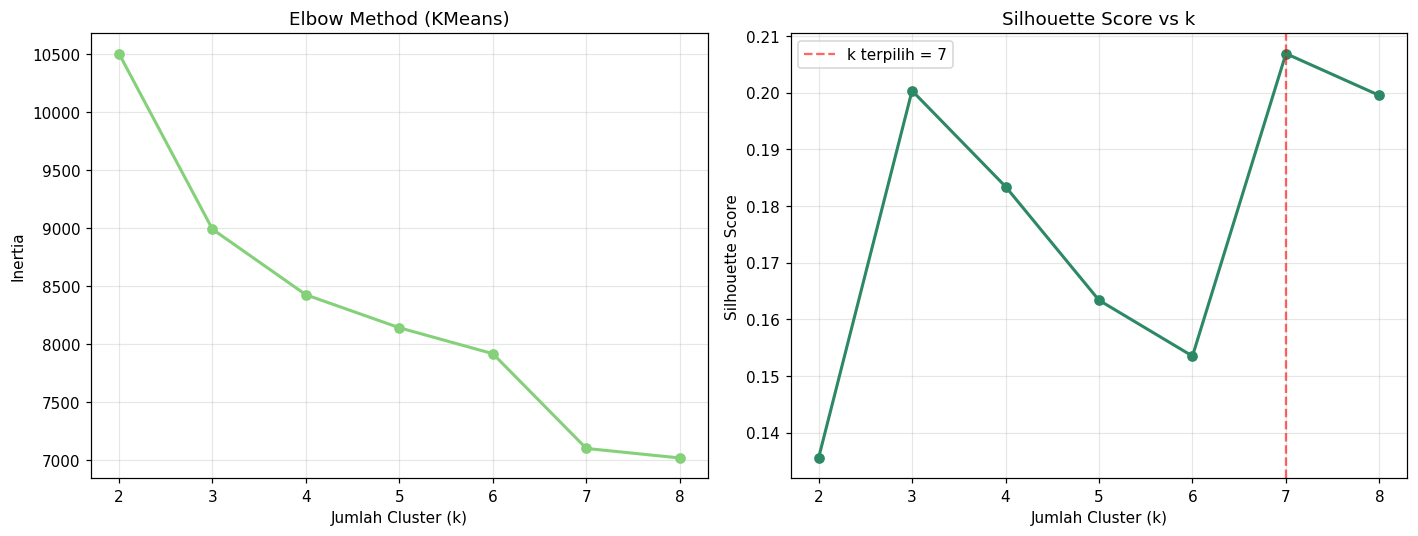

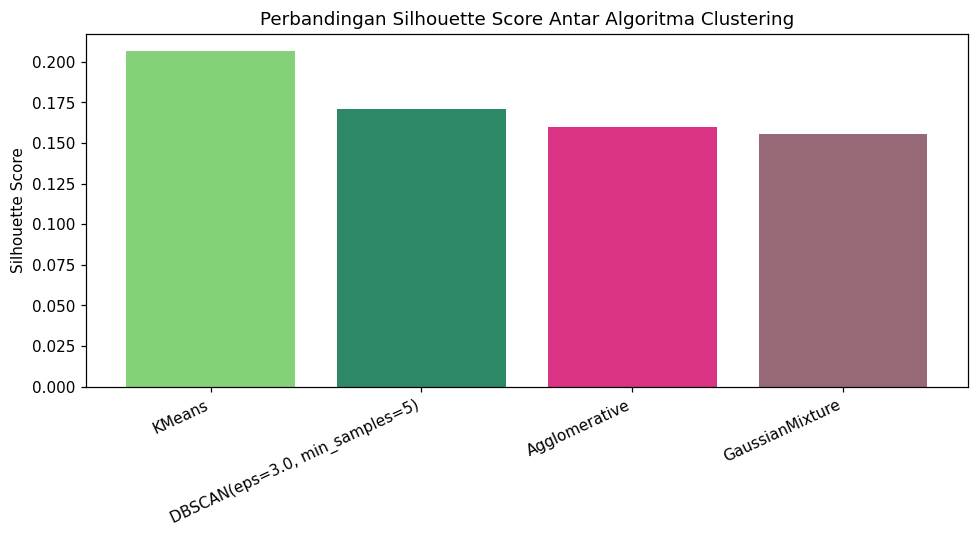

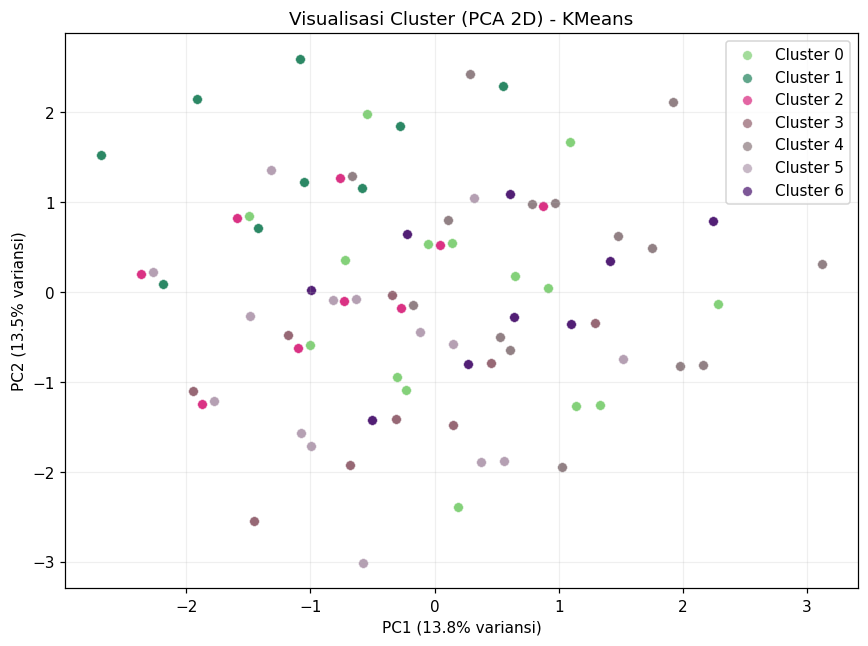

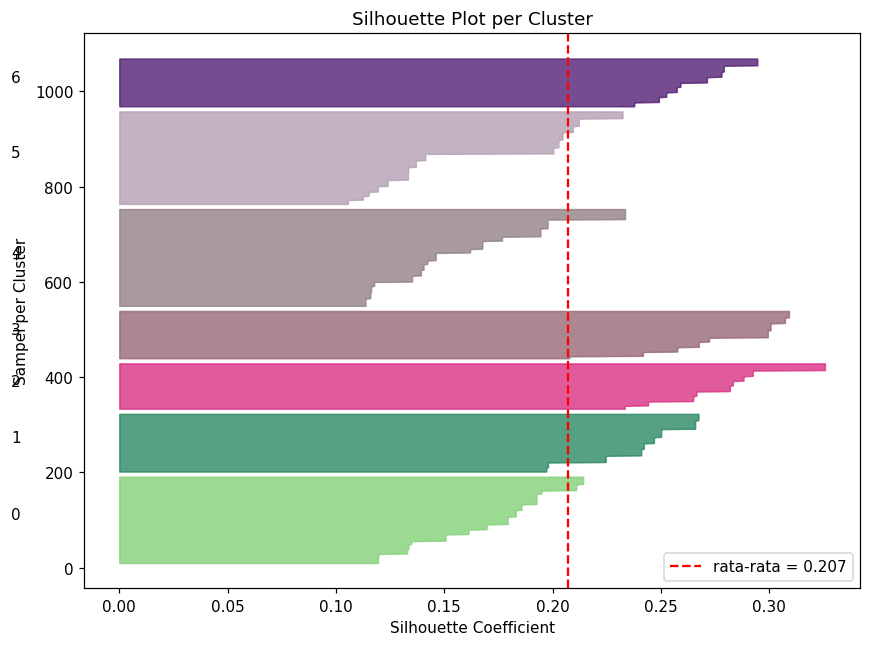

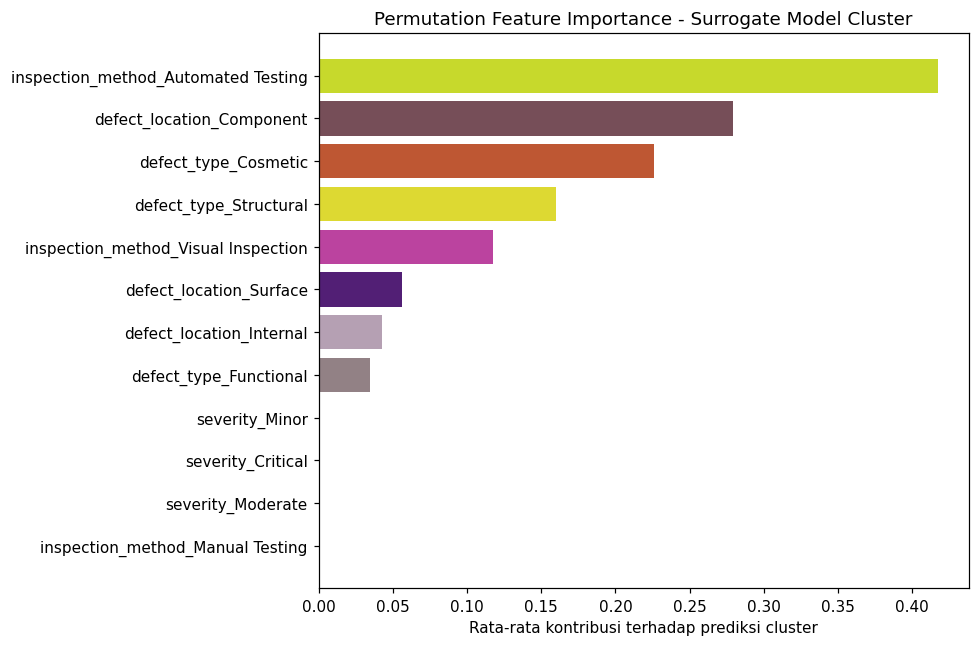

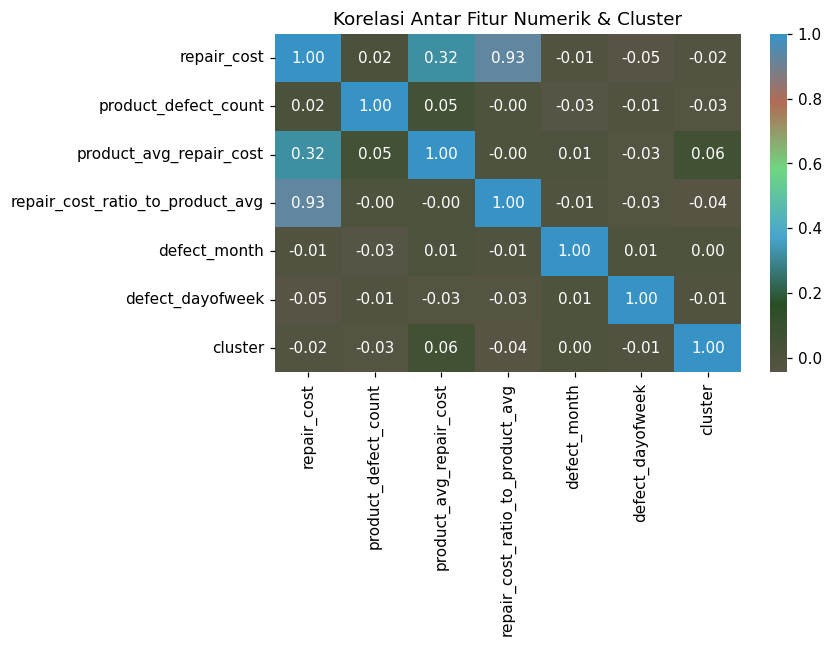

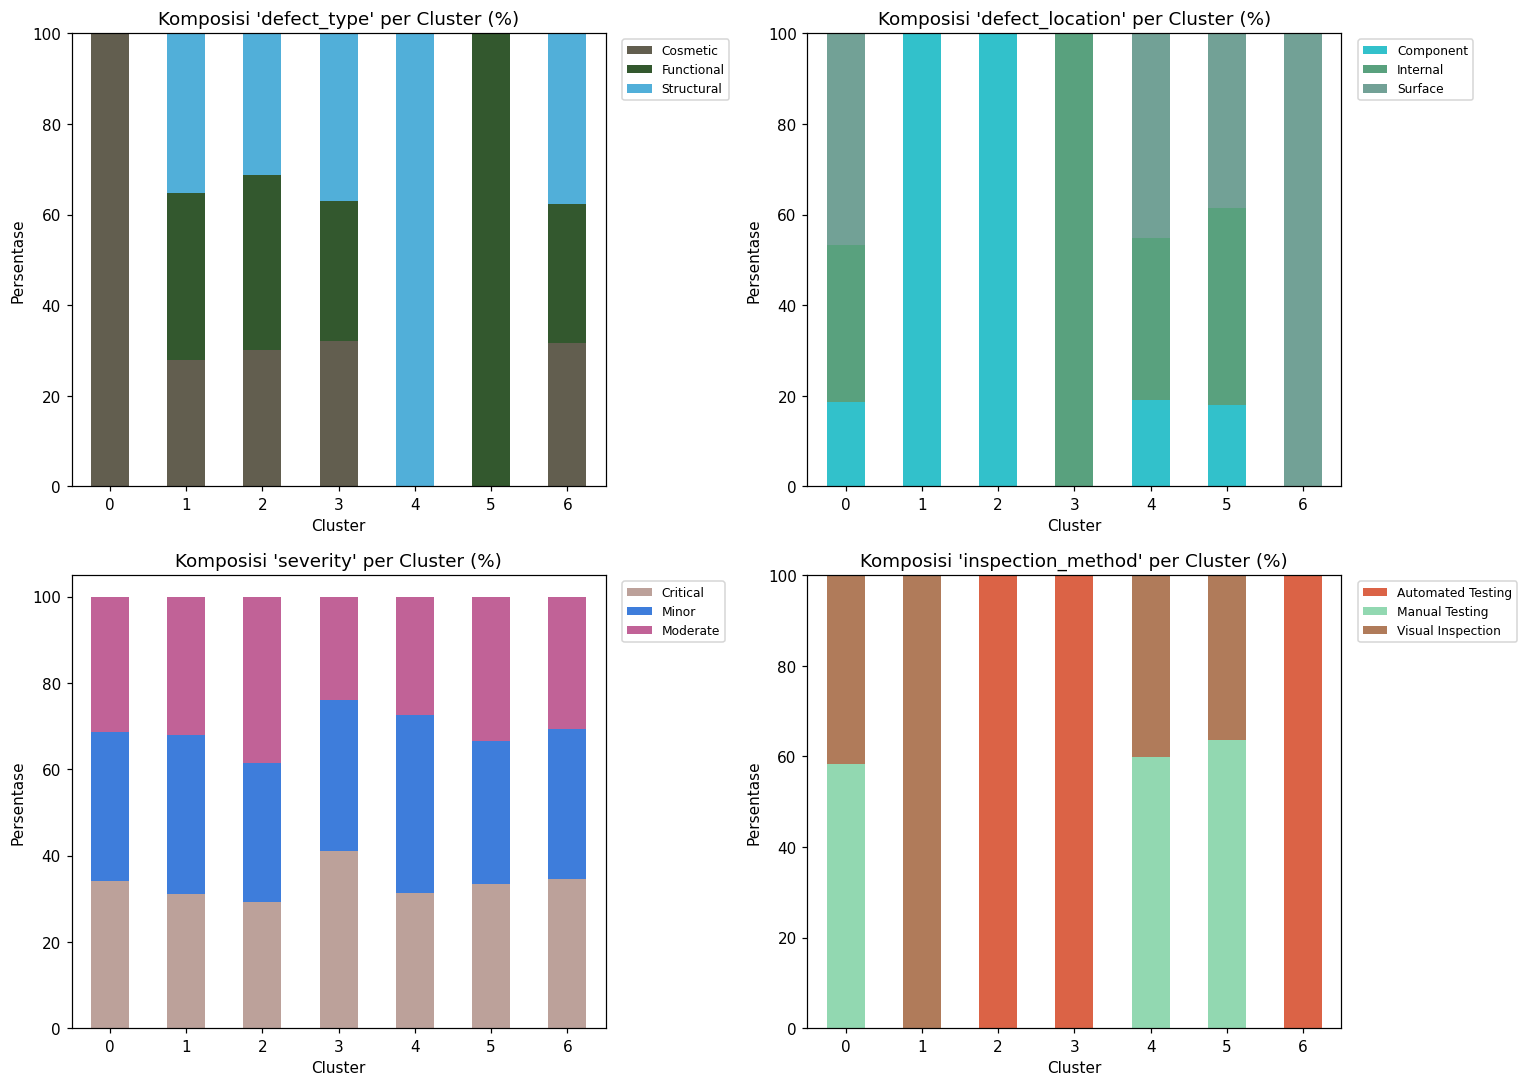

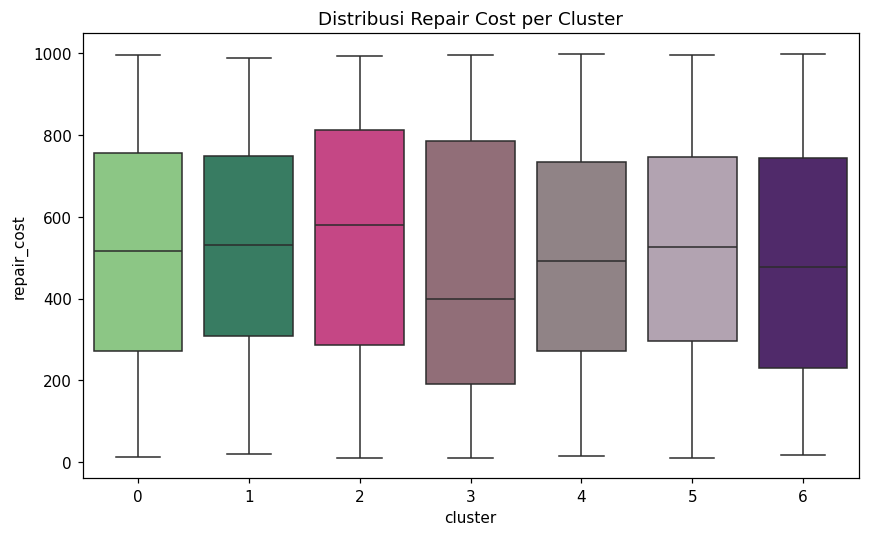

In [16]:
print("\n=== VISUALISASI HASIL ===")

n_clusters_final = len(set(final_labels)) - (1 if -1 in final_labels else 0)
palette = random_rgb_palette(max(n_clusters_final, 1) + 1)
cmap_random = random_cmap()

# 11.1 Elbow + Silhouette plot untuk pemilihan k (KMeans)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(kmeans_scores_df["k"], kmeans_scores_df["inertia"], marker="o",
             color=palette[0], linewidth=2)
axes[0].set_title("Elbow Method (KMeans)")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(kmeans_scores_df["k"], kmeans_scores_df["silhouette"], marker="o",
             color=palette[1 % len(palette)], linewidth=2)
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"k terpilih = {best_k}")
axes[1].set_title("Silhouette Score vs k")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/01_elbow_silhouette.png", dpi=150)
plt.show()

# 11.2 Perbandingan algoritma clustering
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = random_rgb_palette(len(comparison_df))
ax.bar(comparison_df["model"], comparison_df["silhouette"], color=bar_colors)
ax.set_title("Perbandingan Silhouette Score Antar Algoritma Clustering")
ax.set_ylabel("Silhouette Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("outputs/02_model_comparison.png", dpi=150)
plt.show()

# 11.3 PCA 2D scatter plot hasil cluster
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
unique_labels = sorted(set(final_labels))
for i, lab in enumerate(unique_labels):
    mask = final_labels == lab
    color = "lightgray" if lab == -1 else palette[i % len(palette)]
    label_name = "Noise (DBSCAN)" if lab == -1 else f"Cluster {lab}"
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.75, color=color,
               edgecolor="white", linewidth=0.4, label=label_name)
ax.set_title(f"Visualisasi Cluster (PCA 2D) - {final_model_desc}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variansi)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variansi)")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("outputs/03_pca_clusters.png", dpi=150)
plt.show()

# 11.4 Silhouette plot per sampel
fig, ax = plt.subplots(figsize=(8, 6))
sample_silhouette_values = silhouette_samples(X_scaled, final_labels)
y_lower = 10
for i, lab in enumerate(unique_labels):
    if lab == -1:
        continue
    vals = sample_silhouette_values[final_labels == lab]
    vals.sort()
    size = vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                      facecolor=palette[i % len(palette)], edgecolor=palette[i % len(palette)], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size, str(lab))
    y_lower = y_upper + 10
ax.axvline(x=final_sil, color="red", linestyle="--", label=f"rata-rata = {final_sil:.3f}")
ax.set_title("Silhouette Plot per Cluster")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Sampel per Cluster")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/04_silhouette_plot.png", dpi=150)
plt.show()

# 11.5 Feature importance (SHAP / permutation) bar chart
fig, ax = plt.subplots(figsize=(9, 6))
top_feat = feature_importance_df.head(12).sort_values("importance")
ax.barh(top_feat["feature"], top_feat["importance"], color=random_rgb_palette(len(top_feat)))
title_prefix = "SHAP Feature Importance" if shap_available else "Permutation Feature Importance"
ax.set_title(f"{title_prefix} - Surrogate Model Cluster")
ax.set_xlabel("Rata-rata kontribusi terhadap prediksi cluster")
plt.tight_layout()
plt.savefig("outputs/05_feature_importance.png", dpi=150)
plt.show()

# 11.6 Korelasi antar fitur numerik (heatmap dengan cmap RGB random)
numeric_for_corr = ["repair_cost", "product_defect_count", "product_avg_repair_cost",
                     "repair_cost_ratio_to_product_avg", "defect_month", "defect_dayofweek"]
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numeric_for_corr + ["cluster"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap_random, ax=ax, cbar=True)
ax.set_title("Korelasi Antar Fitur Numerik & Cluster")
plt.tight_layout()
plt.savefig("outputs/06_correlation_heatmap.png", dpi=150)
plt.show()

# 11.7 Profil cluster: distribusi kategorikal per cluster (bar chart bertumpuk)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df["cluster"], df[col], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=random_rgb_palette(ct.shape[1], seed=SEED + i + 1))
    axes[i].set_title(f"Komposisi '{col}' per Cluster (%)")
    axes[i].set_ylabel("Persentase")
    axes[i].set_xlabel("Cluster")
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("outputs/07_cluster_profile_categorical.png", dpi=150)
plt.show()

# 11.8 Boxplot repair_cost per cluster
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="cluster", y="repair_cost", ax=ax,
            palette=random_rgb_palette(n_clusters_final + (1 if -1 in final_labels else 0)))
ax.set_title("Distribusi Repair Cost per Cluster")
plt.tight_layout()
plt.savefig("outputs/08_repair_cost_boxplot.png", dpi=150)
plt.show()

## PROFIL & INSIGHT BISNIS PER CLUSTER

In [17]:
print("\n=== PROFIL & INSIGHT BISNIS PER CLUSTER ===")
profile_num = df.groupby("cluster")[numeric_for_corr].mean().round(2)
print("\nRata-rata fitur numerik per cluster:")
print(profile_num)

for lab in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == lab]
    if lab == -1:
        print(f"\n[Cluster Noise / outlier - DBSCAN] -> {len(sub)} baris tidak masuk cluster manapun.")
        continue
    top_type = sub["defect_type"].mode()[0]
    top_loc = sub["defect_location"].mode()[0]
    top_sev = sub["severity"].mode()[0]
    top_insp = sub["inspection_method"].mode()[0]
    avg_cost = sub["repair_cost"].mean()
    print(f"\n[Cluster {lab}] n={len(sub)} baris ({len(sub)/len(df)*100:.1f}% data)")
    print(f"  Dominan defect_type      : {top_type}")
    print(f"  Dominan defect_location  : {top_loc}")
    print(f"  Dominan severity         : {top_sev}")
    print(f"  Dominan inspection_method: {top_insp}")
    print(f"  Rata-rata repair_cost    : {avg_cost:.2f}")


=== PROFIL & INSIGHT BISNIS PER CLUSTER ===

Rata-rata fitur numerik per cluster:
         repair_cost  product_defect_count  product_avg_repair_cost  repair_cost_ratio_to_product_avg  defect_month  defect_dayofweek
cluster                                                                                                                              
0             507.39                 11.71                   500.80                              1.01          3.30              3.09
1             529.00                 11.23                   507.68                              1.05          3.66              3.33
2             541.57                 11.19                   494.28                              1.08          3.32              3.31
3             463.18                 10.99                   506.85                              0.92          3.45              3.05
4             499.54                 11.16                   511.70                              0.98          3.

## SIMPAN HASIL AKHIR

In [18]:
df_out = df_raw.copy()
df_out["cluster"] = final_labels
df_out.to_csv("outputs/defects_data_with_clusters.csv", index=False)
kmeans_scores_df.to_csv("outputs/tuning_kmeans_scores.csv", index=False)
comparison_df.to_csv("outputs/model_comparison.csv", index=False)
feature_importance_df.to_csv("outputs/feature_importance.csv", index=False)

print("\n=== SELESAI ===")
print("Model final :", final_model_desc)
print("Silhouette  :", round(final_sil, 4))
print("File hasil disimpan di folder 'outputs/':")
print(" - defects_data_with_clusters.csv")
print(" - tuning_kmeans_scores.csv, model_comparison.csv, feature_importance.csv")
print(" - 01..08_*.png (semua visualisasi)")


=== SELESAI ===
Model final : KMeans
Silhouette  : 0.2069
File hasil disimpan di folder 'outputs/':
 - defects_data_with_clusters.csv
 - tuning_kmeans_scores.csv, model_comparison.csv, feature_importance.csv
 - 01..08_*.png (semua visualisasi)
